In [1]:
import re
from pathlib import Path

import numpy as np
import meshio
import matplotlib.pyplot as plt

In [2]:
# Paths — adjust BASE if running the notebook from a different working directory
BASE        = Path(".")
DATA_DIR    = BASE / "w7x_coil_0_data"     # coilforce VTU outputs
DOLFINX_DIR = BASE / "w7x_coil_0_dolfinx"  # dolfinx validation VTU outputs

COIL_ID = 0  # index of the base coil to load (coil_00_*)

In [3]:
def discover_n_values(data_dir: Path, dolfinx_dir: Path, coil_id: int) -> list[int]:
    """Return sorted list of n values that have all three required VTU files.

    A valid n value must have:
      data_dir/n_<n>/coil_<id>_run.vtu
      dolfinx_dir/n_<n>/runA_volumetric_BS/coil_<id>_run_dolfinx.vtu
      dolfinx_dir/n_<n>/runB_coilfem_B/coil_<id>_run_dolfinx.vtu
    """
    pat = re.compile(r"^n_(\d+)$")
    prefix = f"coil_{coil_id:02d}"

    valid = []
    for subdir in sorted(data_dir.iterdir()):
        m = pat.match(subdir.name)
        if not m:
            continue
        n = int(m.group(1))

        cf_vtu   = data_dir    / f"n_{n}" / f"{prefix}_run.vtu"
        dfxA_vtu = dolfinx_dir / f"n_{n}" / "runA_volumetric_BS" / f"{prefix}_run_dolfinx.vtu"
        dfxB_vtu = dolfinx_dir / f"n_{n}" / "runB_coilfem_B"     / f"{prefix}_run_dolfinx.vtu"

        if cf_vtu.exists() and dfxA_vtu.exists() and dfxB_vtu.exists():
            valid.append(n)

    return sorted(valid)


n_values = discover_n_values(DATA_DIR, DOLFINX_DIR, COIL_ID)
print(f"Found {len(n_values)} complete n values: {n_values}")

Found 1 complete n values: [100]


In [4]:
def load_vtu(path: Path) -> tuple[dict, dict]:
    """Read a coilforce / dolfinx VTU file and return (node_dict, cell_dict).

    node_dict  — point-data arrays keyed by field name, e.g.:
        'displacement_m'  : (n_nodes, 3) [m]
        'support_weights' : (n_nodes,)
        'spring_k_Npm3'   : (n_nodes,) [N/m^3]

    cell_dict  — cell-data arrays (one value per element), e.g.:
        'von_mises_MPa'   : (n_cells,) [MPa]
        'f_vol_Npm3'      : (n_cells, 3) [N/m^3]
        'B_self_T'        : (n_cells, 3) [T]
        'B_ext_T'         : (n_cells, 3) [T]

    meshio wraps each cell-data array in an extra list (one per cell block);
    we unwrap the first (and only) block here.
    """
    mesh = meshio.read(str(path))
    node_dict = dict(mesh.point_data)
    cell_dict = {k: v[0] for k, v in mesh.cell_data.items()}
    return node_dict, cell_dict

In [5]:
# --- Node-level lists (point data: displacement, support weights, ...) ---
cf_nodes    = []   # CoilFEM            — w7x_coil_0_data
dfx_A_nodes = []   # DolfinX Run A      — runA_volumetric_BS (independent B-field)
dfx_B_nodes = []   # DolfinX Run B      — runB_coilfem_B     (coilforce B-field, elasticity-only)

# --- Cell-centre lists (cell data: von Mises, body force, B fields, ...) ---
cf_cells    = []
dfx_A_cells = []
dfx_B_cells = []

prefix = f"coil_{COIL_ID:02d}"

for n in n_values:
    cf_vtu   = DATA_DIR    / f"n_{n}" / f"{prefix}_run.vtu"
    dfxA_vtu = DOLFINX_DIR / f"n_{n}" / "runA_volumetric_BS" / f"{prefix}_run_dolfinx.vtu"
    dfxB_vtu = DOLFINX_DIR / f"n_{n}" / "runB_coilfem_B"     / f"{prefix}_run_dolfinx.vtu"

    nd, cd = load_vtu(cf_vtu)
    cf_nodes.append({"n": n, **nd})
    cf_cells.append({"n": n, **cd})

    nd, cd = load_vtu(dfxA_vtu)
    dfx_A_nodes.append({"n": n, **nd})
    dfx_A_cells.append({"n": n, **cd})

    nd, cd = load_vtu(dfxB_vtu)
    dfx_B_nodes.append({"n": n, **nd})
    dfx_B_cells.append({"n": n, **cd})

print(f"Loaded {len(cf_nodes)} configurations.")
print(f"Node-level fields  (CoilFEM example): {[k for k in cf_nodes[0] if k != 'n']}")
print(f"Cell-centre fields (CoilFEM example): {[k for k in cf_cells[0] if k != 'n']}")

Loaded 1 configurations.
Node-level fields  (CoilFEM example): ['displacement_m', 'support_weights', 'spring_k_Npm3']
Cell-centre fields (CoilFEM example): ['von_mises_MPa', 'f_vol_Npm3', 'B_self_T', 'B_ext_T']


In [7]:
# Node data
print('Total # cases:', len(dfx_A_nodes))
print(dfx_A_nodes[0].keys())
print(dfx_A_cells[0].keys())


Total # cases: 1
dict_keys(['n', 'displacement_m', 'support_weights', 'spring_k_Npm3'])
dict_keys(['n', 'von_mises_MPa', 'f_vol_Npm3', 'B_self_T', 'B_ext_T'])


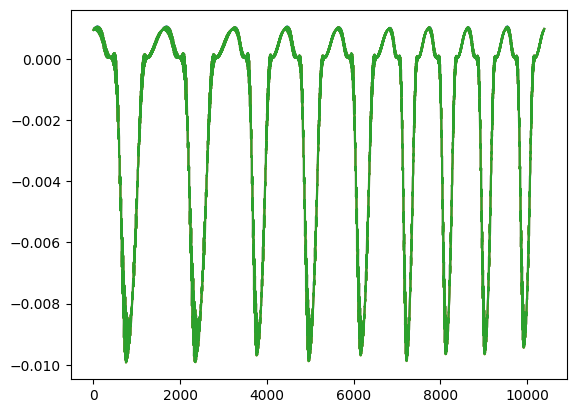

In [8]:
i=0
plt.plot(dfx_A_nodes[i]['displacement_m'][:, 0])
plt.plot(dfx_B_nodes[i]['displacement_m'][:, 0])
plt.plot(cf_nodes[i]['displacement_m'][:, 0])

In [9]:
dfx_A_nodes[0]['spring_k_Npm3'].shape

(10400,)

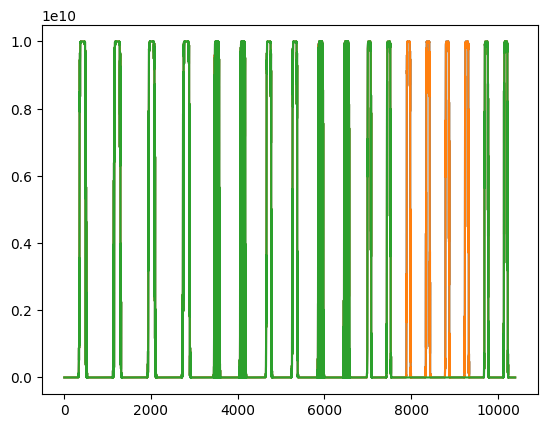

In [10]:
plt.plot(dfx_A_nodes[i]['spring_k_Npm3'])
plt.plot(dfx_B_nodes[i]['spring_k_Npm3'])
plt.plot(cf_nodes[i]['spring_k_Npm3'])

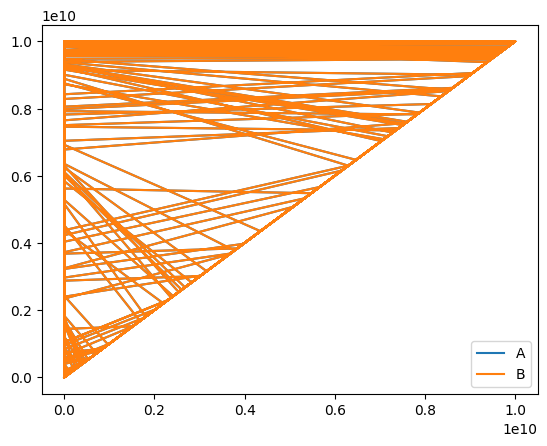

In [11]:
plt.plot(
    cf_nodes[i]['spring_k_Npm3'], 
    dfx_A_nodes[i]['spring_k_Npm3'],
    label='A'
)
plt.plot(
    cf_nodes[i]['spring_k_Npm3'],
    dfx_B_nodes[i]['spring_k_Npm3'],
    label='B'
)
plt.legend()

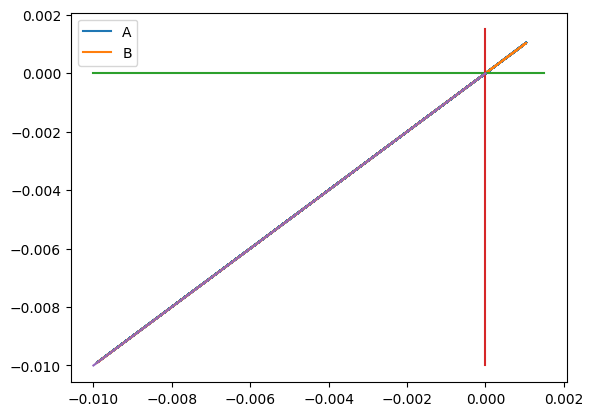

In [13]:
plt.plot(
    cf_nodes[i]['displacement_m'][:, 0], 
    dfx_A_nodes[i]['displacement_m'][:, 0],
    label='A'
)
plt.plot(
    cf_nodes[i]['displacement_m'][:, 0],
    dfx_B_nodes[i]['displacement_m'][:, 0],
    label='B'
)
plt.plot([-.01, 0.0015], [0, 0])
plt.plot([0, 0], [-.01, 0.0015])
plt.plot([-.01, 0], [-.01, 0])
plt.legend()

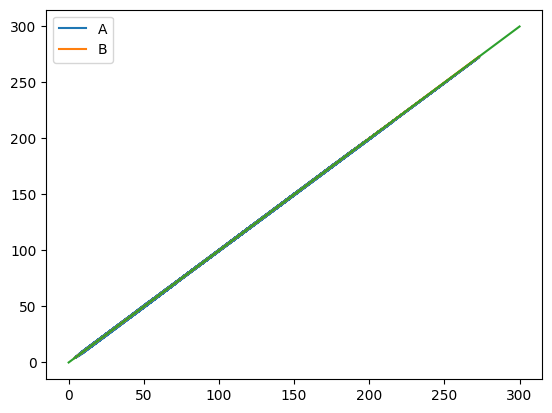

In [14]:
plt.plot(
    cf_cells[i]['von_mises_MPa'], 
    dfx_A_cells[i]['von_mises_MPa'],
    label='A'
)
plt.plot(
    cf_cells[i]['von_mises_MPa'],
    dfx_B_cells[i]['von_mises_MPa'],
    label='B'
)
plt.plot([0, 300], [0, 300])
plt.legend()

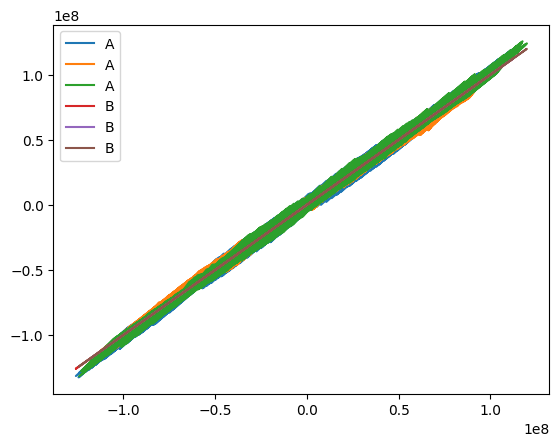

In [15]:
plt.plot(
    cf_cells[i]['f_vol_Npm3'], 
    dfx_A_cells[i]['f_vol_Npm3'],
    label='A'
)
plt.plot(
    cf_cells[i]['f_vol_Npm3'],
    dfx_B_cells[i]['f_vol_Npm3'],
    label='B'
)
plt.legend()

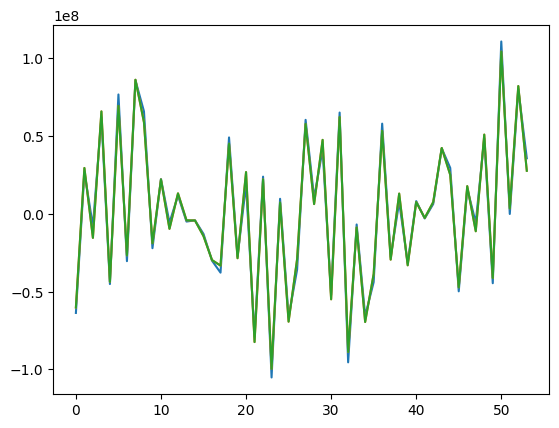

In [16]:
plt.plot(dfx_A_cells[0]['f_vol_Npm3'][::100, 0])
plt.plot(dfx_B_cells[0]['f_vol_Npm3'][::100, 0])
plt.plot(cf_cells[0]['f_vol_Npm3'][::100, 0])

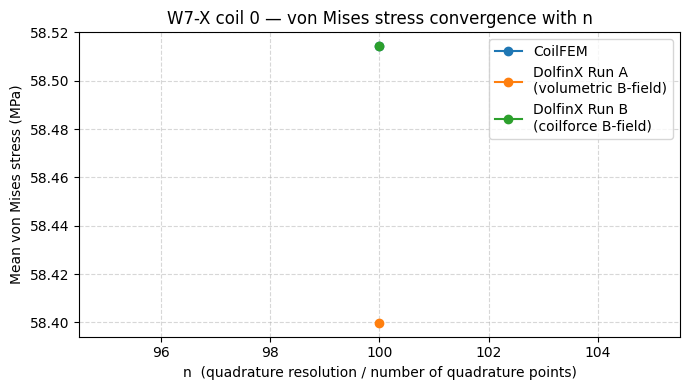

In [17]:
# Average von Mises stress (MPa) per configuration for each data source.
# von_mises_MPa is a cell-centre scalar, so we average over all elements.
sources = [
    ("CoilFEM",       cf_cells),
    ("DolfinX Run A\n(volumetric B-field)", dfx_A_cells),
    ("DolfinX Run B\n(coilforce B-field)",  dfx_B_cells),
]

fig, ax = plt.subplots(figsize=(7, 4))

for label, cells in sources:
    ns  = [d["n"]                       for d in cells]
    vms = [d["von_mises_MPa"].mean()    for d in cells]
    ax.plot(ns, vms, marker="o", label=label)

ax.set_xlabel("n  (quadrature resolution / number of quadrature points)")
ax.set_ylabel("Mean von Mises stress (MPa)")
ax.set_title("W7-X coil 0 — von Mises stress convergence with n")
ax.legend(loc="best")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

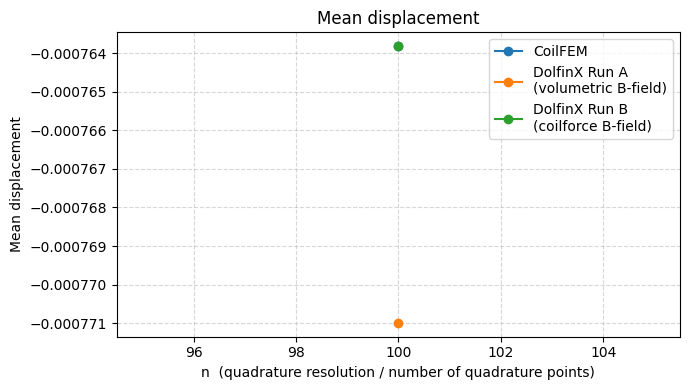

In [18]:
# Average von Mises stress (MPa) per configuration for each data source.
# von_mises_MPa is a cell-centre scalar, so we average over all elements.
sources = [
    ("CoilFEM",       cf_nodes),
    ("DolfinX Run A\n(volumetric B-field)", dfx_A_nodes),
    ("DolfinX Run B\n(coilforce B-field)",  dfx_B_nodes),
]

fig, ax = plt.subplots(figsize=(7, 4))

for label, cells in sources:
    ns  = [d["n"]                       for d in cells]
    vms = [d["displacement_m"].mean()    for d in cells]
    ax.plot(ns, vms, marker="o", label=label)

ax.set_xlabel("n  (quadrature resolution / number of quadrature points)")
ax.set_ylabel("Mean displacement")
ax.set_title("Mean displacement")
ax.legend(loc="best")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()